In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.diagnostic import acorr_ljungbox

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file_path = "/content/drive/MyDrive/project_ts.xlsx"
df = pd.read_excel(file_path)
df.columns = [c.strip() for c in df.columns]
df['Date'] = pd.to_datetime(df['Date'].str.split(' ').str[0])
for col in ['Income', 'Outcome', 'Balance']:
    s = (df[col].astype(str)
                .str.replace(',', '.', regex=False)
                .str.replace(' ', '', regex=False))
    df[col] = pd.to_numeric(s, errors='coerce').fillna(0.0)

df = df.sort_values('Date').drop_duplicates(subset='Date').reset_index(drop=True)

df['is_active'] = (df['Income'].abs() + df['Outcome'].abs()) > 0.0
df.loc[~df['is_active'], ['Income', 'Outcome', 'Balance']] = 0.0
df.head(5)

,Date,Income,Outcome,Balance,is_active
0,2017-01-09,1.343028,1.487865,-0.155904,True
1,2017-01-10,1.068610,1.194182,-0.125572,True
2,2017-01-11,0.944429,0.936663,0.007767,True
3,2017-01-12,1.672202,0.875379,0.800391,True
4,2017-01-13,0.955924,0.975645,-0.019721,True


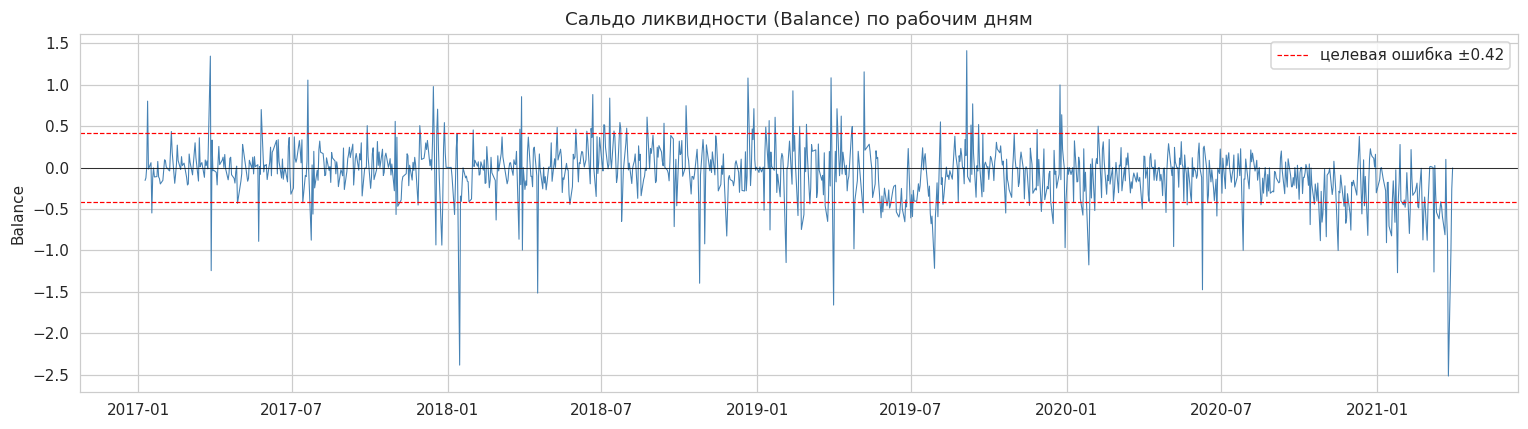

In [3]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

active = df[df['is_active']].copy()
active['dow']   = active['Date'].dt.day_name()
active['dom']   = active['Date'].dt.day
active['month'] = active['Date'].dt.month
active['year']  = active['Date'].dt.year

# сальдо во времени
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(active['Date'], active['Balance'], lw=0.7, color='steelblue')
ax.axhline(0,     color='black', lw=0.5)
ax.axhline( 0.42, color='red', ls='--', lw=0.8, label='целевая ошибка ±0.42')
ax.axhline(-0.42, color='red', ls='--', lw=0.8)
ax.set_title('Сальдо ликвидности (Balance) по рабочим дням')
ax.set_ylabel('Balance')
ax.legend()
plt.tight_layout(); plt.show()


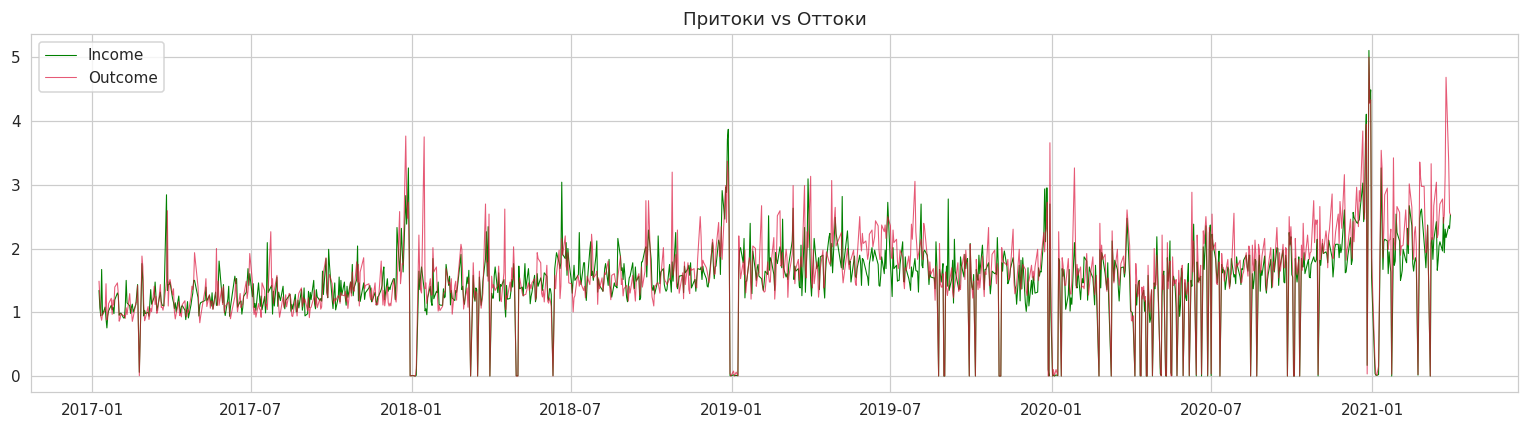

In [4]:
# Income vs Outcome
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(active['Date'], active['Income'],  lw=0.7, label='Income',  color='green')
ax.plot(active['Date'], active['Outcome'], lw=0.7, label='Outcome', color='crimson', alpha=0.7)
ax.set_title('Притоки vs Оттоки')
ax.legend()
plt.tight_layout(); plt.show()

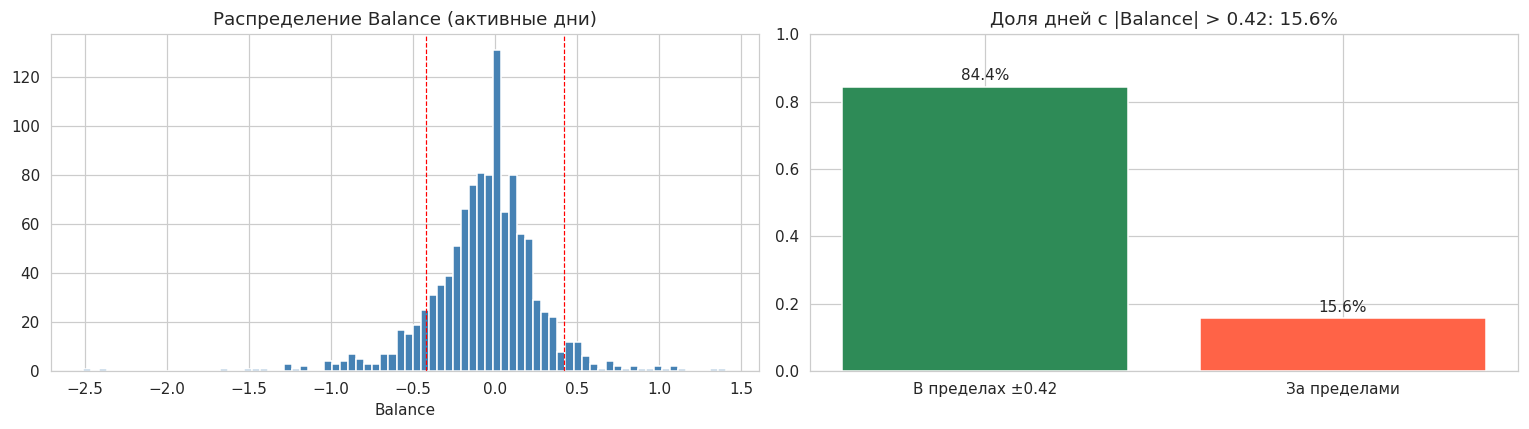

In [5]:
# распределение баланса
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(active['Balance'], bins=80, color='steelblue', edgecolor='white')
axes[0].axvline( 0.42, color='red', ls='--', lw=0.8)
axes[0].axvline(-0.42, color='red', ls='--', lw=0.8)
axes[0].set_title('Распределение Balance (активные дни)')
axes[0].set_xlabel('Balance')

# доля наблюдений за пределами целевой ошибки
out_of_target = (active['Balance'].abs() > 0.42).mean()
axes[1].bar(['В пределах ±0.42', 'За пределами'],
            [1 - out_of_target, out_of_target],
            color=['seagreen', 'tomato'])
axes[1].set_title(f'Доля дней с |Balance| > 0.42: {out_of_target:.1%}')
axes[1].set_ylim(0, 1)
for i, v in enumerate([1 - out_of_target, out_of_target]):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center')
plt.tight_layout(); plt.show()

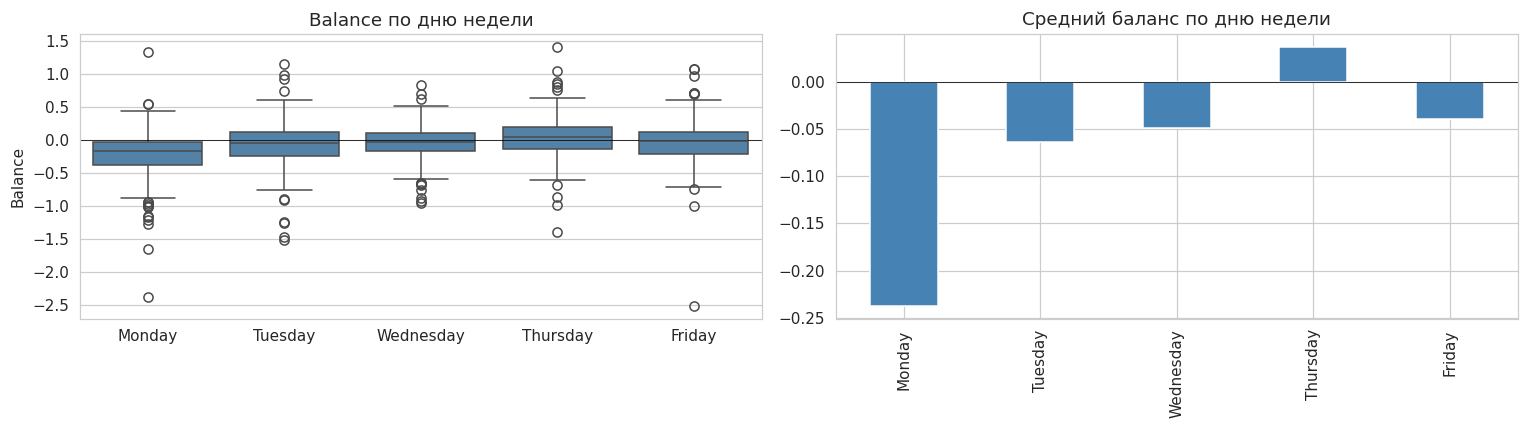

In [6]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=active, x='dow', y='Balance', order=dow_order, ax=axes[0],
            color='steelblue')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title('Balance по дню недели')
axes[0].set_xlabel('')

active.groupby('dow')['Balance'].mean().reindex(dow_order).plot(
    kind='bar', ax=axes[1], color='steelblue')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title('Средний баланс по дню недели')
axes[1].set_xlabel('')
plt.tight_layout(); plt.show()

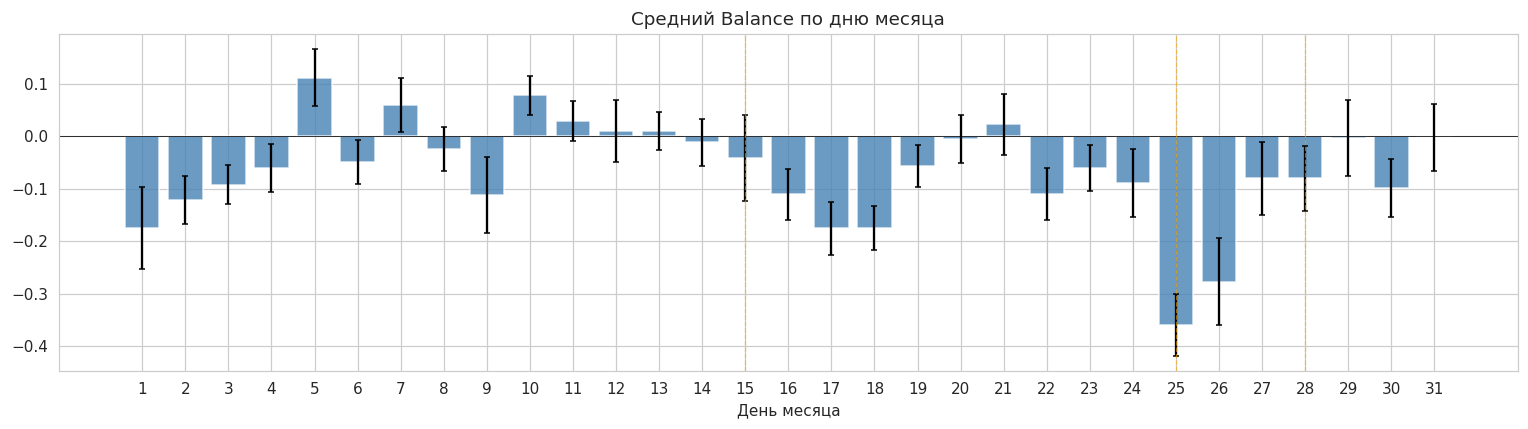

In [7]:
# по дням месяца
fig, ax = plt.subplots(figsize=(14, 4))
dom_stats = active.groupby('dom')['Balance'].agg(['mean','std','count'])
ax.bar(dom_stats.index, dom_stats['mean'],
       yerr=dom_stats['std']/np.sqrt(dom_stats['count']),
       color='steelblue', alpha=0.8, capsize=2)
ax.axhline(0, color='black', lw=0.5)
for d in [15, 25, 28]:
    ax.axvline(d, color='orange', ls='--', lw=0.8, alpha=0.6)
ax.set_title('Средний Balance по дню месяца')
ax.set_xlabel('День месяца')
ax.set_xticks(range(1, 32))
plt.tight_layout(); plt.show()

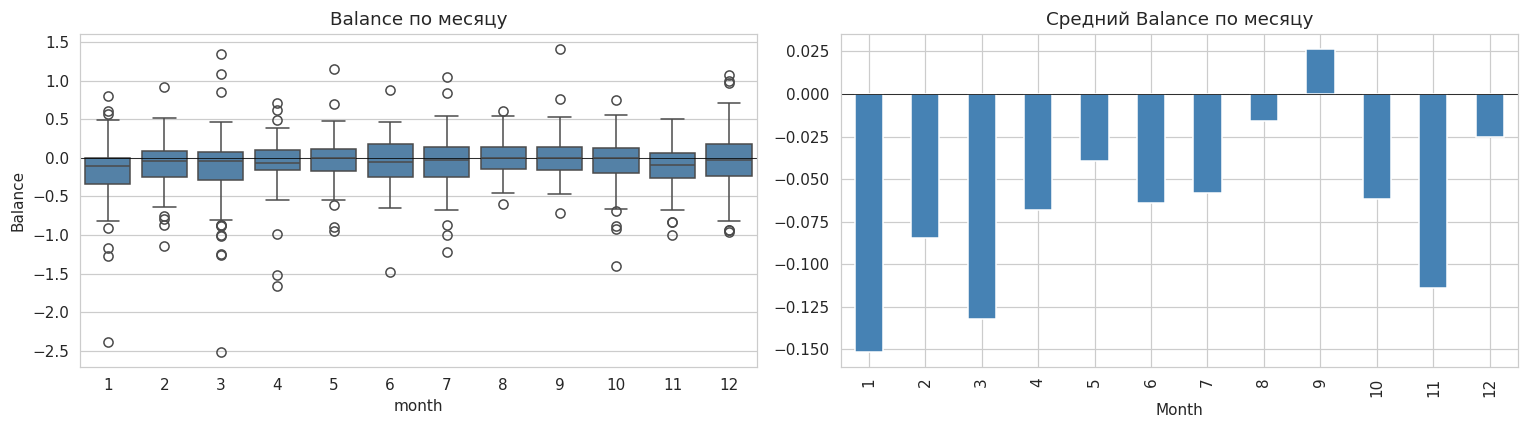

In [8]:
# --- 2.6 По месяцу года (сезонность) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=active, x='month', y='Balance', ax=axes[0], color='steelblue')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title('Balance по месяцу')

active.groupby('month')['Balance'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title('Средний Balance по месяцу')
axes[1].set_xlabel('Month')
plt.tight_layout(); plt.show()

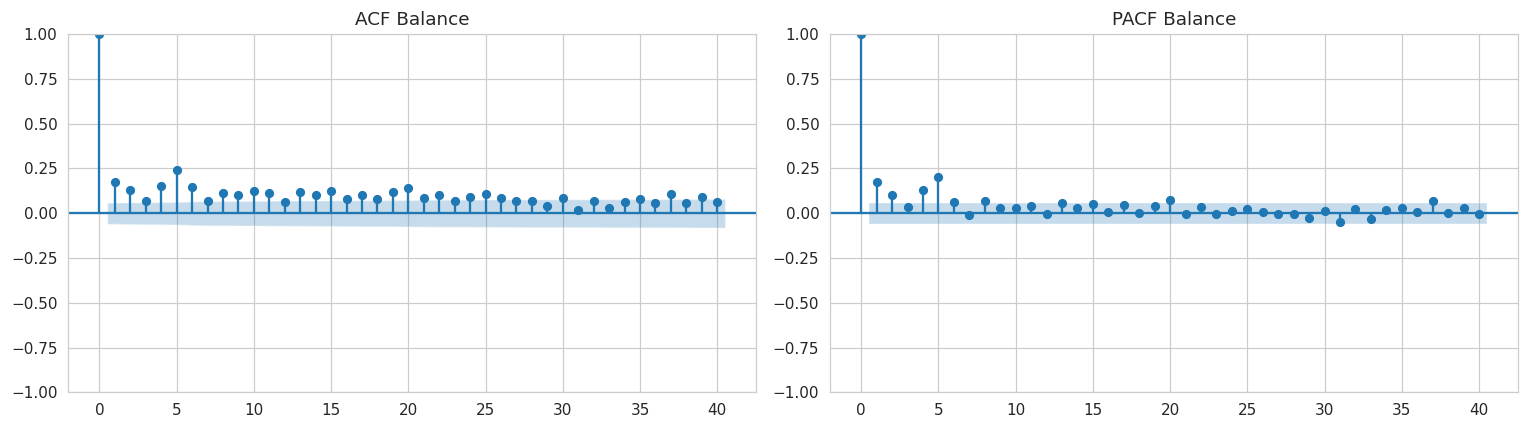

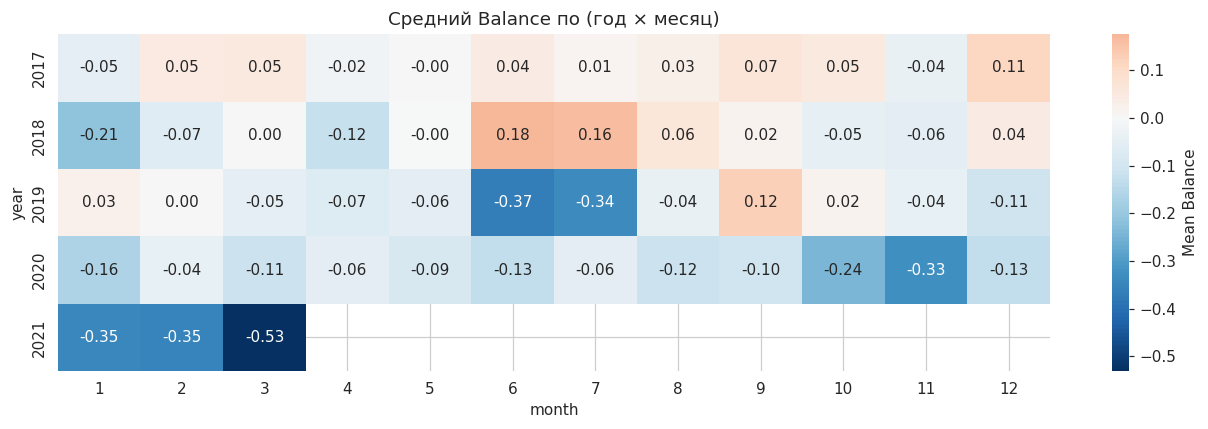

In [9]:
# автокорреляция и частичная автокорреляция
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf (active['Balance'], lags=40, ax=axes[0])
plot_pacf(active['Balance'], lags=40, ax=axes[1], method='ywm')
axes[0].set_title('ACF Balance');  axes[1].set_title('PACF Balance')
plt.tight_layout(); plt.show()

# heatmap
pivot = active.pivot_table(index='year', columns='month',
                            values='Balance', aggfunc='mean')
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'Mean Balance'})
ax.set_title('Средний Balance по (год × месяц)')
plt.tight_layout(); plt.show()

In [10]:
def make_target_features(df: pd.DataFrame,
                         lags=(1, 2, 3, 5, 10, 20),
                         roll_windows=(5, 10, 20),
                         ewm_spans=(5, 20)) -> pd.DataFrame:
    out = df[['Date']].copy()
    active = df[df['is_active']].copy().reset_index(drop=True)

    # лаги
    for L in lags:
        active[f'balance_lag_{L}'] = active['Balance'].shift(L)
        active[f'income_lag_{L}']  = active['Income'].shift(L)
        active[f'outcome_lag_{L}'] = active['Outcome'].shift(L)

    # скользящие
    for W in roll_windows:
        b_sh = active['Balance'].shift(1)
        i_sh = active['Income'].shift(1)
        o_sh = active['Outcome'].shift(1)
        active[f'balance_rollmean_{W}'] = b_sh.rolling(W, min_periods=2).mean()
        active[f'balance_rollstd_{W}']  = b_sh.rolling(W, min_periods=2).std()
        active[f'balance_rollmin_{W}']  = b_sh.rolling(W, min_periods=2).min()
        active[f'balance_rollmax_{W}']  = b_sh.rolling(W, min_periods=2).max()
        active[f'income_rollmean_{W}']  = i_sh.rolling(W, min_periods=2).mean()
        active[f'outcome_rollmean_{W}'] = o_sh.rolling(W, min_periods=2).mean()

    for S in ewm_spans:
        active[f'balance_ewm_{S}'] = (active['Balance'].shift(1)
                                              .ewm(span=S, adjust=False).mean())

    # разности
    active['balance_diff_1'] = active['Balance'].shift(1) - active['Balance'].shift(2)
    active['balance_diff_5'] = active['Balance'].shift(1) - active['Balance'].shift(6)

    # знак вчерашнего баланса
    active['balance_sign_lag1'] = np.sign(active['Balance'].shift(1))

    # отношения Income/Outcome вчера
    out_lag = active['Outcome'].shift(1)
    active['io_ratio_lag1'] = np.where(out_lag.abs() > 1e-9,
                                       active['Income'].shift(1) / out_lag,
                                       np.nan)

    # |Balance| вчера и его сглаживание (proxy волатильности)
    active['abs_balance_lag1']    = active['Balance'].shift(1).abs()
    active['abs_balance_ewm_10']  = active['Balance'].shift(1).abs().ewm(span=10, adjust=False).mean()

    keep = [c for c in active.columns
            if c not in ['Income', 'Outcome', 'Balance', 'is_active']]
    return out.merge(active[keep], on='Date', how='left')

In [11]:
f_tgt = make_target_features(df)
f_tgt.columns

Index(['Date', 'balance_lag_1', 'income_lag_1', 'outcome_lag_1',
       'balance_lag_2', 'income_lag_2', 'outcome_lag_2', 'balance_lag_3',
       'income_lag_3', 'outcome_lag_3', 'balance_lag_5', 'income_lag_5',
       'outcome_lag_5', 'balance_lag_10', 'income_lag_10', 'outcome_lag_10',
       'balance_lag_20', 'income_lag_20', 'outcome_lag_20',
       'balance_rollmean_5', 'balance_rollstd_5', 'balance_rollmin_5',
       'balance_rollmax_5', 'income_rollmean_5', 'outcome_rollmean_5',
       'balance_rollmean_10', 'balance_rollstd_10', 'balance_rollmin_10',
       'balance_rollmax_10', 'income_rollmean_10', 'outcome_rollmean_10',
       'balance_rollmean_20', 'balance_rollstd_20', 'balance_rollmin_20',
       'balance_rollmax_20', 'income_rollmean_20', 'outcome_rollmean_20',
       'balance_ewm_5', 'balance_ewm_20', 'balance_diff_1', 'balance_diff_5',
       'balance_sign_lag1', 'io_ratio_lag1', 'abs_balance_lag1',
       'abs_balance_ewm_10'],
      dtype='object')

# Календарные фичи

In [12]:
import holidays

ru_holidays = holidays.country_holidays('RU')

In [13]:

RU_CAL = holidays.country_holidays('RU', years=range(2015, 2031))

def _is_ru_holiday(date: pd.Timestamp) -> bool:
    """Государственный праздник РФ."""
    return date in RU_CAL

def _is_nonworking(date: pd.Timestamp) -> bool:
    """Нерабочий день: выходной (Sat/Sun) ИЛИ праздник."""
    return date.weekday() >= 5 or _is_ru_holiday(date)


def make_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df[['Date']].copy()
    d = out['Date']

    out['dow']     = d.dt.dayofweek    # 0=Mon, 6=Sun
    out['dom']     = d.dt.day
    out['month']   = d.dt.month
    out['quarter'] = d.dt.quarter
    out['year']    = d.dt.year


    # --- Позиция в месяце/квартале/году ---
    out['days_to_month_end']     = (d + pd.offsets.MonthEnd(0) - d).dt.days
    out['days_from_month_start'] = d.dt.day - 1

    out['is_month_end_5d']   = (out['days_to_month_end'] <= 5).astype(int)
    out['is_month_end_1d']   = (out['days_to_month_end'] == 0).astype(int)
    out['is_month_start_5d'] = (out['days_from_month_start'] <= 4).astype(int)
    out['is_quarter_end_5d'] = (out['month'].isin([3, 6, 9, 12]) &
                                (out['days_to_month_end'] <= 5)).astype(int)
    out['is_year_end_10d']   = ((out['month'] == 12) &
                                (out['days_to_month_end'] <= 10)).astype(int)
    out['is_year_start_10d'] = ((out['month'] == 1) &
                                (out['days_from_month_start'] <= 9)).astype(int)

    # --- Праздничные флаги ---
    # Векторизуем через isin вместо apply — быстрее на больших данных
    holiday_set = pd.Series(list(RU_CAL.keys())).pipe(pd.to_datetime)
    out['is_holiday']    = d.isin(holiday_set).astype(int)
    out['is_nonworking'] = ((d.dt.dayofweek >= 5) | out['is_holiday'].astype(bool)).astype(int)

    # --- Длина серии нерабочих дней ПЕРЕД текущей датой ---
    runs = []
    cur_run = 0
    last_was_nw = False
    for is_nw in out['is_nonworking'].values:
        if is_nw:
            cur_run += 1
            runs.append(0)
            last_was_nw = True
        else:
            runs.append(cur_run if last_was_nw else 0)
            cur_run = 0
            last_was_nw = False

    out['holiday_run_before']    = runs
    out['is_post_holiday']       = (out['holiday_run_before'] >= 2).astype(int)
    out['is_post_long_holiday']  = (out['holiday_run_before'] >= 3).astype(int)

    return out

In [14]:
f_cal = make_calendar_features(df)
f_cal

,Date,dow,dom,month,quarter,year,days_to_month_end,days_from_month_start,is_month_end_5d,is_month_end_1d,is_month_start_5d,is_quarter_end_5d,is_year_end_10d,is_year_start_10d,is_holiday,is_nonworking,holiday_run_before,is_post_holiday,is_post_long_holiday
0,2017-01-09,0,9,1,1,2017,22,8,0,0,0,0,0,1,0,0,0,0,0
1,2017-01-10,1,10,1,1,2017,21,9,0,0,0,0,0,1,0,0,0,0,0
2,2017-01-11,2,11,1,1,2017,20,10,0,0,0,0,0,0,0,0,0,0,0
3,2017-01-12,3,12,1,1,2017,19,11,0,0,0,0,0,0,0,0,0,0,0
4,2017-01-13,4,13,1,1,2017,18,12,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1538,2021-03-27,5,27,3,1,2021,4,26,1,0,0,1,0,0,0,1,0,0,0
1539,2021-03-28,6,28,3,1,2021,3,27,1,0,0,1,0,0,0,1,0,0,0
1540,2021-03-29,0,29,3,1,2021,2,28,1,0,0,1,0,0,0,0,2,1,0
1541,2021-03-30,1,30,3,1,2021,1,29,1,0,0,1,0,0,0,0,0,0,0


# Налоговые фичи

In [15]:

TAX_DAYS = [15, 25, 28]
QUARTER_TAX_MONTHS = {1, 4, 7, 10}

def make_tax_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df[['Date']].copy()
    dom = out['Date'].dt.day

    for td in TAX_DAYS:
        diff = dom - td
        out[f'days_to_tax_{td}']    = -diff
        out[f'is_tax_{td}_window']  = (diff.abs() <= 3).astype(int)
        out[f'is_tax_{td}_day']     = (dom == td).astype(int)
        out[f'is_pre_tax_{td}_3d']  = ((diff >= -3) & (diff < 0)).astype(int)
        out[f'is_post_tax_{td}_3d'] = ((diff > 0) & (diff <= 3)).astype(int)

    out['is_quarter_tax_month']  = out['Date'].dt.month.isin(QUARTER_TAX_MONTHS).astype(int)
    out['is_quarter_tax_window'] = (out['is_quarter_tax_month'] &
                                    (out['days_to_tax_25'].abs() <= 5)).astype(int)
    return out

In [16]:
f_tax = make_tax_features(df)

# Макро фичи

In [17]:
# ставка цб
import requests
import pandas as pd
from xml.etree import ElementTree as ET

def load_cbr_key_rate(date_from: str, date_to: str) -> pd.DataFrame:
    """
    Загружает ключевую ставку ЦБ РФ за период.
    date_from, date_to: строки 'YYYY-MM-DD'.
    Возвращает DataFrame: Date, cbr_key_rate (только даты изменения ставки).
    """
    url = 'https://www.cbr.ru/DailyInfoWebServ/DailyInfo.asmx'
    body = f"""<?xml version="1.0" encoding="utf-8"?>
<soap:Envelope xmlns:soap="http://schemas.xmlsoap.org/soap/envelope/">
  <soap:Body>
    <KeyRate xmlns="http://web.cbr.ru/">
      <fromDate>{date_from}T00:00:00</fromDate>
      <ToDate>{date_to}T00:00:00</ToDate>
    </KeyRate>
  </soap:Body>
</soap:Envelope>"""
    headers = {
        'Content-Type': 'text/xml; charset=utf-8',
        'SOAPAction': 'http://web.cbr.ru/KeyRate',
    }
    r = requests.post(url, data=body.encode('utf-8'), headers=headers, timeout=15)
    r.raise_for_status()

    root = ET.fromstring(r.content)
    rows = []
    # В ответе ЦБ есть namespaces, поэтому ищем по суффиксам тегов
    for kr in root.iter():
        if kr.tag.endswith('KR'):
            date = rate = None
            for child in kr:
                if child.tag.endswith('DT'):    date = child.text
                if child.tag.endswith('Rate'):  rate = child.text
            if date and rate:
                # tz_localize(None) — сбрасываем московскую таймзону, нормализуем дату
                ts = pd.Timestamp(date).tz_localize(None).normalize()
                rows.append({'Date': ts, 'cbr_key_rate': float(rate)})

    return pd.DataFrame(rows).sort_values('Date').reset_index(drop=True)


raw = load_cbr_key_rate('2017-01-01', '2021-03-31')
print(f'Получено точек: {len(raw)}')
print(raw)

Получено точек: 1053
           Date  cbr_key_rate
0    2017-01-09          10.0
1    2017-01-10          10.0
2    2017-01-11          10.0
3    2017-01-12          10.0
4    2017-01-13          10.0
...         ...           ...
1048 2021-03-25           4.5
1049 2021-03-26           4.5
1050 2021-03-29           4.5
1051 2021-03-30           4.5
1052 2021-03-31           4.5

[1053 rows x 2 columns]


In [18]:
# Ежедневный календарь за нужный период
full_dates = pd.DataFrame({
    'Date': pd.date_range('2017-01-01', '2021-03-31', freq='D')
})

# Подмердживаем редкие точки и forward-fill'им
key_rate = full_dates.merge(raw, on='Date', how='left')
key_rate['cbr_key_rate'] = key_rate['cbr_key_rate'].ffill()

# Если первые дни до первой точки ЦБ — будут NaN. Заполним backward fill
# (берём ближайшее будущее значение). Это маленький костыль для начала ряда.
key_rate['cbr_key_rate'] = key_rate['cbr_key_rate'].bfill()

print(key_rate.head())
print(f'\nДней с NaN: {key_rate["cbr_key_rate"].isna().sum()}')
print(f'Уникальных значений ставки: {key_rate["cbr_key_rate"].nunique()}')

        Date  cbr_key_rate
0 2017-01-01          10.0
1 2017-01-02          10.0
2 2017-01-03          10.0
3 2017-01-04          10.0
4 2017-01-05          10.0

Дней с NaN: 0
Уникальных значений ставки: 16


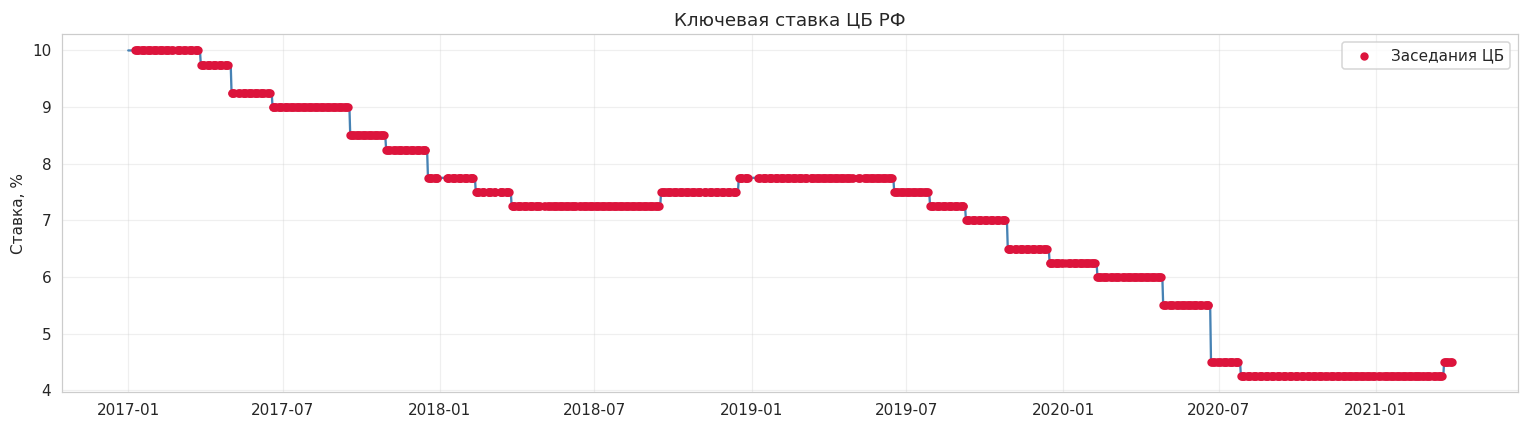

In [19]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(key_rate['Date'], key_rate['cbr_key_rate'],
        color='steelblue', lw=1.5)
# Точки заседаний ЦБ — маленькие маркеры
ax.scatter(raw['Date'], raw['cbr_key_rate'],
           color='crimson', s=20, zorder=3, label='Заседания ЦБ')
ax.set_title('Ключевая ставка ЦБ РФ')
ax.set_ylabel('Ставка, %')
ax.set_xlabel('')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
def load_ruonia(date_from: str, date_to: str) -> pd.DataFrame:
    """
    Загружает RUONIA за период. Публикуется по рабочим дням.
    """
    url = 'https://www.cbr.ru/DailyInfoWebServ/DailyInfo.asmx'
    body = f"""<?xml version="1.0" encoding="utf-8"?>
<soap:Envelope xmlns:soap="http://schemas.xmlsoap.org/soap/envelope/">
  <soap:Body>
    <Ruonia xmlns="http://web.cbr.ru/">
      <fromDate>{date_from}T00:00:00</fromDate>
      <ToDate>{date_to}T00:00:00</ToDate>
    </Ruonia>
  </soap:Body>
</soap:Envelope>"""
    headers = {
        'Content-Type': 'text/xml; charset=utf-8',
        'SOAPAction': 'http://web.cbr.ru/Ruonia',
    }
    r = requests.post(url, data=body.encode('utf-8'), headers=headers, timeout=15)
    r.raise_for_status()

    root = ET.fromstring(r.content)
    rows = []
    for ro in root.iter():
        if ro.tag.endswith('ro'):
            date = rate = None
            for child in ro:
                if child.tag.endswith('D0'):   date = child.text
                if child.tag.endswith('ruo'):  rate = child.text
            if date and rate:
                ts = pd.Timestamp(date).tz_localize(None).normalize()
                rows.append({'Date': ts, 'ruonia': float(rate)})

    return pd.DataFrame(rows).sort_values('Date').reset_index(drop=True)


# Запускаем
ruonia_raw = load_ruonia('2017-01-01', '2021-03-31')
print(ruonia_raw.head())
print(ruonia_raw.tail())

        Date  ruonia
0 2017-01-09   10.13
1 2017-01-10    9.93
2 2017-01-11    9.97
3 2017-01-12    9.93
4 2017-01-13   10.06
           Date  ruonia
1029 2021-03-25    4.41
1030 2021-03-26    4.31
1031 2021-03-29    4.45
1032 2021-03-30    4.48
1033 2021-03-31    4.45


In [21]:
ruonia = full_dates.merge(ruonia_raw, on='Date', how='left')
ruonia['ruonia'] = ruonia['ruonia'].ffill().bfill()

# Склеиваем с ключевой ставкой и считаем спред
macro = key_rate.merge(ruonia, on='Date', how='left')
macro['ruonia_minus_key'] = macro['ruonia'] - macro['cbr_key_rate']

print(macro.tail(10))
print(f'\nСтатистика спреда RUONIA - Key:')
print(macro['ruonia_minus_key'].describe().round(3))

           Date  cbr_key_rate  ruonia  ruonia_minus_key
1541 2021-03-22           4.5    4.24             -0.26
1542 2021-03-23           4.5    4.22             -0.28
1543 2021-03-24           4.5    4.28             -0.22
1544 2021-03-25           4.5    4.41             -0.09
1545 2021-03-26           4.5    4.31             -0.19
1546 2021-03-27           4.5    4.31             -0.19
1547 2021-03-28           4.5    4.31             -0.19
1548 2021-03-29           4.5    4.45             -0.05
1549 2021-03-30           4.5    4.48             -0.02
1550 2021-03-31           4.5    4.45             -0.05

Статистика спреда RUONIA - Key:
count    1551.000
mean       -0.187
std         0.219
min        -0.970
25%        -0.280
50%        -0.180
75%        -0.050
max         0.490
Name: ruonia_minus_key, dtype: float64


           Date  cbr_key_rate  ruonia  ruonia_minus_key
1541 2021-03-22           4.5    4.24             -0.26
1542 2021-03-23           4.5    4.22             -0.28
1543 2021-03-24           4.5    4.28             -0.22
1544 2021-03-25           4.5    4.41             -0.09
1545 2021-03-26           4.5    4.31             -0.19
1546 2021-03-27           4.5    4.31             -0.19
1547 2021-03-28           4.5    4.31             -0.19
1548 2021-03-29           4.5    4.45             -0.05
1549 2021-03-30           4.5    4.48             -0.02
1550 2021-03-31           4.5    4.45             -0.05

Статистика спреда RUONIA - Key:
count    1551.000
mean       -0.187
std         0.219
min        -0.970
25%        -0.280
50%        -0.180
75%        -0.050
max         0.490
Name: ruonia_minus_key, dtype: float64


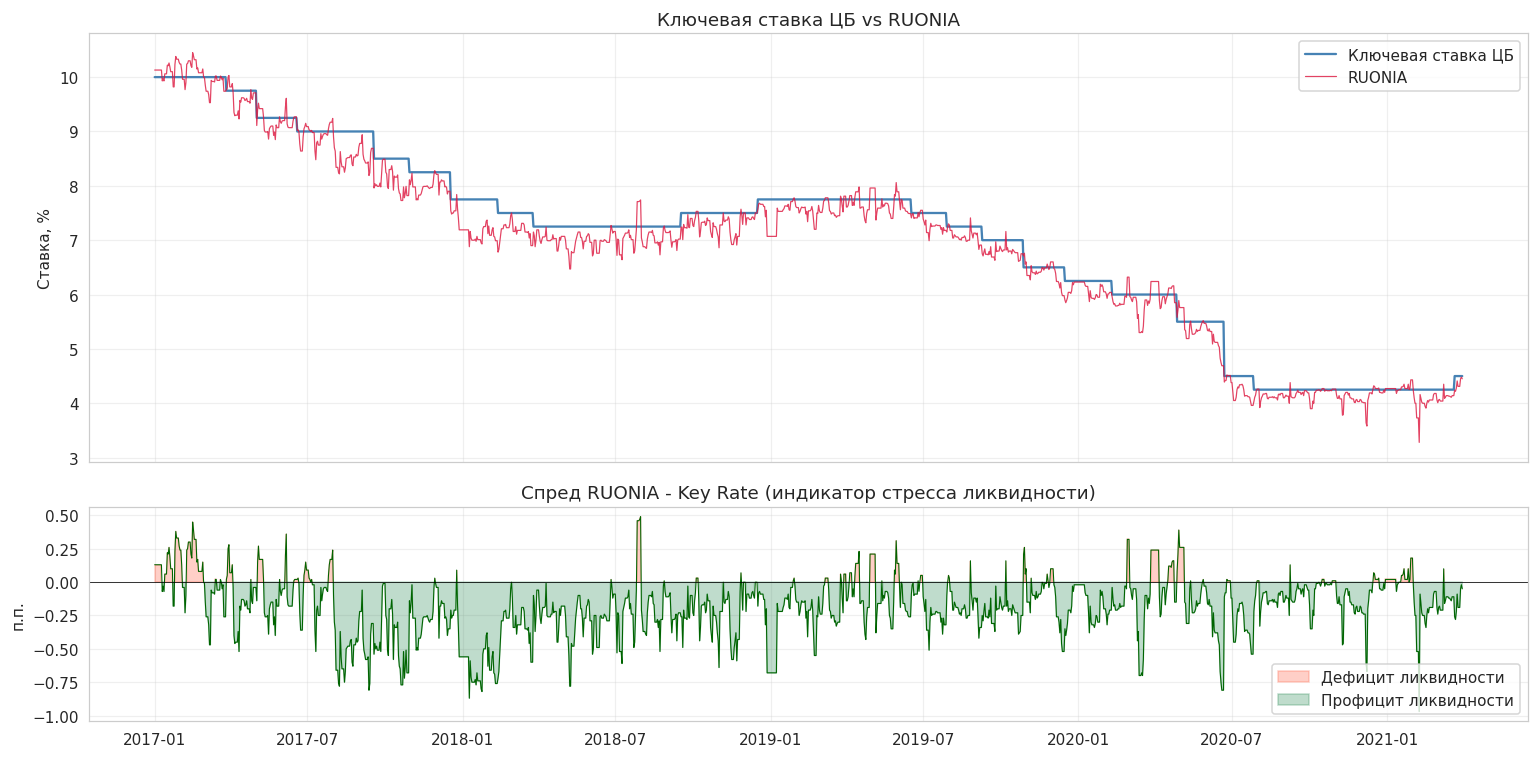

In [22]:
ruonia = full_dates.merge(ruonia_raw, on='Date', how='left')
ruonia['ruonia'] = ruonia['ruonia'].ffill().bfill()

# Склеиваем с ключевой ставкой и считаем спред
macro = key_rate.merge(ruonia, on='Date', how='left')
macro['ruonia_minus_key'] = macro['ruonia'] - macro['cbr_key_rate']

print(macro.tail(10))
print(f'\nСтатистика спреда RUONIA - Key:')
print(macro['ruonia_minus_key'].describe().round(3))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

# Верхняя панель: обе ставки
axes[0].plot(macro['Date'], macro['cbr_key_rate'],
             color='steelblue', lw=1.5, label='Ключевая ставка ЦБ')
axes[0].plot(macro['Date'], macro['ruonia'],
             color='crimson', lw=0.8, alpha=0.8, label='RUONIA')
axes[0].set_title('Ключевая ставка ЦБ vs RUONIA')
axes[0].set_ylabel('Ставка, %')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Нижняя панель: спред
axes[1].plot(macro['Date'], macro['ruonia_minus_key'],
             color='darkgreen', lw=0.7)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].fill_between(macro['Date'], 0, macro['ruonia_minus_key'],
                     where=macro['ruonia_minus_key'] > 0,
                     color='tomato', alpha=0.3, label='Дефицит ликвидности')
axes[1].fill_between(macro['Date'], 0, macro['ruonia_minus_key'],
                     where=macro['ruonia_minus_key'] < 0,
                     color='seagreen', alpha=0.3, label='Профицит ликвидности')
axes[1].set_title('Спред RUONIA - Key Rate (индикатор стресса ликвидности)')
axes[1].set_ylabel('п.п.')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Курс валют рублю к доллару

In [23]:
def load_usd_rub(date_from: str, date_to: str) -> pd.DataFrame:
    """
    Загружает официальный курс USD/RUB ЦБ за период.
    Публикуется по рабочим дням.
    """
    d_from = pd.Timestamp(date_from).strftime('%d/%m/%Y')
    d_to   = pd.Timestamp(date_to).strftime('%d/%m/%Y')
    url = (f'https://www.cbr.ru/scripts/XML_dynamic.asp'
           f'?date_req1={d_from}&date_req2={d_to}&VAL_NM_RQ=R01235')

    r = requests.get(url, timeout=15)
    r.raise_for_status()

    root = ET.fromstring(r.content)
    rows = []
    for rec in root.findall('Record'):
      date = pd.to_datetime(rec.attrib['Date'], dayfirst=True).normalize()
      value   = float(rec.find('Value').text.replace(',', '.'))
      nominal = float(rec.find('Nominal').text)
      rows.append({'Date': date, 'usd_rub': value / nominal})

    return pd.DataFrame(rows).sort_values('Date').reset_index(drop=True)


# Запускаем
usd_raw = load_usd_rub('2017-01-01', '2021-03-31')
print(f'Получено точек: {len(usd_raw)}')
print(usd_raw.head())
print(usd_raw.tail())
print(f'\nДиапазон курса: {usd_raw["usd_rub"].min():.2f} ... {usd_raw["usd_rub"].max():.2f}')

Получено точек: 1039
        Date  usd_rub
0 2017-01-10  59.8961
1 2017-01-11  59.9533
2 2017-01-12  60.1614
3 2017-01-13  59.4978
4 2017-01-14  59.3700
           Date  usd_rub
1034 2021-03-25  76.1535
1035 2021-03-26  76.1741
1036 2021-03-27  75.7576
1037 2021-03-30  75.8287
1038 2021-03-31  75.7023

Диапазон курса: 55.67 ... 80.88


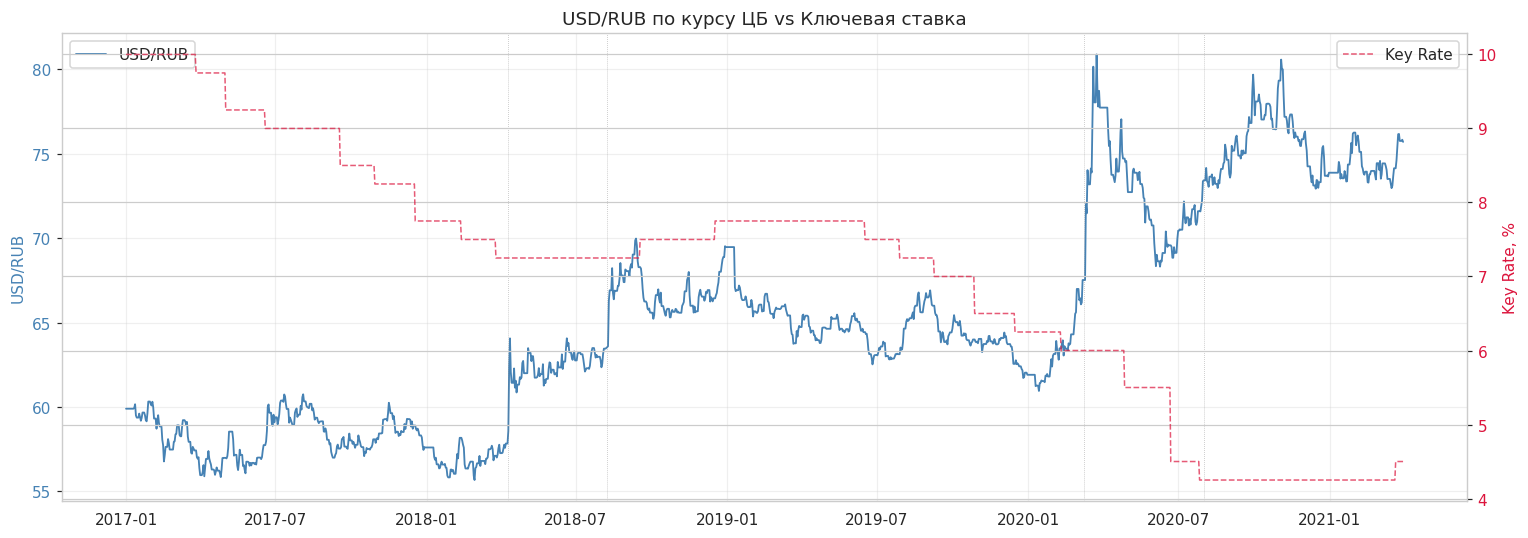

In [24]:
usd = full_dates.merge(usd_raw, on='Date', how='left')
usd['usd_rub'] = usd['usd_rub'].ffill().bfill()

# Подмердживаем в macro
macro = macro.merge(usd, on='Date', how='left')

fig, ax1 = plt.subplots(figsize=(14, 5))

# Левая ось — курс
ax1.plot(macro['Date'], macro['usd_rub'],
         color='steelblue', lw=1.2, label='USD/RUB')
ax1.set_ylabel('USD/RUB', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(True, alpha=0.3)

# Правая ось — ключевая ставка для контекста
ax2 = ax1.twinx()
ax2.plot(macro['Date'], macro['cbr_key_rate'],
         color='crimson', lw=1, ls='--', alpha=0.7, label='Key Rate')
ax2.set_ylabel('Key Rate, %', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

ax1.set_title('USD/RUB по курсу ЦБ vs Ключевая ставка')

# Подсвечиваем ключевые события
events = {
    '2018-04-09':  'Санкции\n(Русал)',
    '2018-08-08':  'Санкции\n(спикер ГД)',
    '2020-03-09':  'Нефтяной шок\n+ COVID',
    '2020-08-01':  'Минимум ставки',
}
for date, label in events.items():
    d = pd.Timestamp(date)
    ax1.axvline(d, color='gray', lw=0.5, ls=':', alpha=0.6)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [25]:
macro

,Date,cbr_key_rate,ruonia,ruonia_minus_key,usd_rub
0,2017-01-01,10.0,10.13,0.13,59.8961
1,2017-01-02,10.0,10.13,0.13,59.8961
2,2017-01-03,10.0,10.13,0.13,59.8961
3,2017-01-04,10.0,10.13,0.13,59.8961
4,2017-01-05,10.0,10.13,0.13,59.8961
...,...,...,...,...,...
1546,2021-03-27,4.5,4.31,-0.19,75.7576
1547,2021-03-28,4.5,4.31,-0.19,75.7576
1548,2021-03-29,4.5,4.45,-0.05,75.7576
1549,2021-03-30,4.5,4.48,-0.02,75.8287


In [26]:
def make_macro_features(macro: pd.DataFrame) -> pd.DataFrame:
    out = macro[['Date']].copy()
    for col in ['cbr_key_rate', 'ruonia', 'usd_rub', 'ruonia_minus_key']:
        if col in macro.columns:
            out[f'{col}_lag1']  = macro[col].shift(1)
            out[f'{col}_diff5'] = macro[col].shift(1) - macro[col].shift(6)
    return out

f_mac = make_macro_features(macro)

# Объединяем все в одно

In [27]:
X = (df[['Date', 'Balance', 'is_active']]
     .merge(f_tgt, on='Date', how='left')
     .merge(f_cal, on='Date', how='left')
     .merge(f_tax, on='Date', how='left')
     .merge(f_mac, on='Date', how='left'))

In [28]:
X = X[X['is_active']].drop(columns=['is_active']).reset_index(drop=True)

# Шаг 5: dropna от лагов
print(f'До dropna: {X.shape}')
X = X.dropna().reset_index(drop=True)
print(f'После dropna: {X.shape}')

До dropna: (1112, 89)
После dropna: (1082, 89)


In [29]:
y = X['Balance']
X_features = X.drop(columns=['Date', 'Balance'])


In [30]:
print(f'\nТаргет y: shape={y.shape}')
print(f'Матрица X_features: shape={X_features.shape}')
print(f'Период: {X["Date"].min().date()} .. {X["Date"].max().date()}')

# Шаг 7: группировка фичей
def get_groups(cols):
    return {
        'TARGET_LAGS':    [c for c in cols if any(k in c for k in
                          ['_lag_', 'diff_', 'sign_lag', 'io_ratio', 'abs_balance_lag'])],
        'TARGET_ROLLING': [c for c in cols if 'roll' in c or 'ewm' in c],
        'CALENDAR':       [c for c in cols if c in {
            'dow','dom','month','quarter','year',
            'dow_sin','dow_cos','month_sin','month_cos','dom_sin','dom_cos',
            'days_to_month_end','days_from_month_start',
            'is_month_end_5d','is_month_end_1d','is_month_start_5d',
            'is_quarter_end_5d','is_year_end_10d','is_year_start_10d'
        }],
        'HOLIDAYS':       [c for c in cols if c in {
            'is_holiday','is_nonworking',
            'holiday_run_before','is_post_holiday','is_post_long_holiday'
        }],
        'TAX':            [c for c in cols if 'tax' in c],
        'MACRO':          [c for c in cols if any(k in c for k in
                          ['cbr_','ruonia','usd_rub'])]
    }

groups = get_groups(X_features.columns.tolist())
groups


Таргет y: shape=(1082,)
Матрица X_features: shape=(1082, 87)
Период: 2017-02-06 .. 2021-03-31


{'TARGET_LAGS': ['balance_lag_1',
  'income_lag_1',
  'outcome_lag_1',
  'balance_lag_2',
  'income_lag_2',
  'outcome_lag_2',
  'balance_lag_3',
  'income_lag_3',
  'outcome_lag_3',
  'balance_lag_5',
  'income_lag_5',
  'outcome_lag_5',
  'balance_lag_10',
  'income_lag_10',
  'outcome_lag_10',
  'balance_lag_20',
  'income_lag_20',
  'outcome_lag_20',
  'balance_diff_1',
  'balance_diff_5',
  'balance_sign_lag1',
  'io_ratio_lag1',
  'abs_balance_lag1'],
 'TARGET_ROLLING': ['balance_rollmean_5',
  'balance_rollstd_5',
  'balance_rollmin_5',
  'balance_rollmax_5',
  'income_rollmean_5',
  'outcome_rollmean_5',
  'balance_rollmean_10',
  'balance_rollstd_10',
  'balance_rollmin_10',
  'balance_rollmax_10',
  'income_rollmean_10',
  'outcome_rollmean_10',
  'balance_rollmean_20',
  'balance_rollstd_20',
  'balance_rollmin_20',
  'balance_rollmax_20',
  'income_rollmean_20',
  'outcome_rollmean_20',
  'balance_ewm_5',
  'balance_ewm_20',
  'abs_balance_ewm_10'],
 'CALENDAR': ['dow',
  '

Посмотрим на стабильность

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr

RANDOM_STATE = 42


# ============================================================
# Меры стабильности (из лекции 6)
# ============================================================
def jaccard(si: set, sj: set) -> float:
    """|si ∩ sj| / |si ∪ sj|. Симметричная, [0,1]."""
    if not si and not sj:
        return 1.0
    return len(si & sj) / len(si | sj)

def dice(si: set, sj: set) -> float:
    """2|si ∩ sj| / (|si| + |sj|). Чувствительнее Jaccard к пересечению."""
    if not si and not sj:
        return 1.0
    return 2 * len(si & sj) / (len(si) + len(sj))

def kuncheva(si: set, sj: set, d: int) -> float:
    """
    Индекс Кунчевой. d — общее число фичей.
    Корректирует на случайность: учитывает, что для равных |si|=|sj|=k
    ожидаемое случайное пересечение = k²/d.
    Требует |si| == |sj| (поэтому методы возвращают фиксированный k).
    """
    k = len(si)
    if k == 0 or k != len(sj) or k == d:
        return np.nan
    observed = len(si & sj)
    expected = k * k / d
    return (observed - expected) / (k - expected)


def stability(feature_sets: list[set], d: int, measure='jaccard') -> float:
    """
    Φ(Z) — среднее попарное значение меры по всем парам feature_sets.
    feature_sets: список set'ов имён фичей (по одному на фолд CV).
    d: общее число фичей-кандидатов.
    """
    funcs = {'jaccard': lambda a, b: jaccard(a, b),
             'dice':    lambda a, b: dice(a, b),
             'kuncheva': lambda a, b: kuncheva(a, b, d)}
    f = funcs[measure]
    pairs = list(combinations(feature_sets, 2))
    if not pairs:
        return np.nan
    vals = [f(a, b) for a, b in pairs]
    return float(np.nanmean(vals))


In [32]:
TOP_K = 20   # сколько фичей отбираем каждым методом

def fs_spearman(X: pd.DataFrame, y: pd.Series, k: int = TOP_K) -> set:
    """Фильтр, линейный: top-k по |Spearman(X_i, y)|."""
    scores = {}
    for col in X.columns:
        rho, _ = spearmanr(X[col], y)
        scores[col] = abs(rho) if not np.isnan(rho) else 0.0
    top = sorted(scores, key=scores.get, reverse=True)[:k]
    return set(top)


def fs_mutual_info(X: pd.DataFrame, y: pd.Series, k: int = TOP_K) -> set:
    """Фильтр, нелинейный: top-k по mutual information."""
    mi = mutual_info_regression(X, y, random_state=RANDOM_STATE)
    order = np.argsort(mi)[::-1]
    return set(X.columns[order[:k]])


def fs_lasso(X: pd.DataFrame, y: pd.Series, k: int = TOP_K) -> set:
    """
    Встроенный, линейный: top-k по |β_i| из LassoCV.
    LassoCV сам подбирает alpha по CV, берём топ-k по абсолютной величине
    коэффициентов (Lasso даёт разреженность, но фиксируем k для сравнения).
    """
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    model = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=10000, n_jobs=-1)
    model.fit(Xs, y)
    coefs = np.abs(model.coef_)
    order = np.argsort(coefs)[::-1]
    return set(X.columns[order[:k]])


def fs_rfe_rf(X: pd.DataFrame, y: pd.Series, k: int = TOP_K) -> set:
    """
    Оберточный, нелинейный (RFE поверх Random Forest)
    Рекурсивно убирает фичи с наименьшей вкладом до тех пор, пока не останется k
    """
    rf = RandomForestRegressor(n_estimators=100, max_depth=8,
                               random_state=RANDOM_STATE, n_jobs=-1)
    rfe = RFE(estimator=rf, n_features_to_select=k, step=0.1)
    rfe.fit(X, y)
    return set(X.columns[rfe.support_])


METHODS = {
    'Spearman (filter, lin)':    fs_spearman,
    'Mutual Info (filter, nl)':  fs_mutual_info,
    'Lasso (embedded, lin)':     fs_lasso,
    'RFE+RF (wrapper, nl)':      fs_rfe_rf,
}

In [33]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# для каждого метода feature_sets[method] = [set_fold_1, ..., set_fold_5]
feature_sets = {name: [] for name in METHODS}

for fold_i, (train_idx, test_idx) in enumerate(tscv.split(X_features)):
    X_train = X_features.iloc[train_idx]
    y_train = y.iloc[train_idx]

    print(f'Fold {fold_i+1}/{N_SPLITS}  train={len(X_train)}')
    for name, fn in METHODS.items():
        sel = fn(X_train, y_train, k=TOP_K)
        feature_sets[name].append(sel)
        print(f'  {name:30s} → {len(sel)} фичей')

print('\nГотово.')

Fold 1/5  train=182
  Spearman (filter, lin)         → 20 фичей
  Mutual Info (filter, nl)       → 20 фичей
  Lasso (embedded, lin)          → 20 фичей
  RFE+RF (wrapper, nl)           → 20 фичей
Fold 2/5  train=362
  Spearman (filter, lin)         → 20 фичей
  Mutual Info (filter, nl)       → 20 фичей
  Lasso (embedded, lin)          → 20 фичей
  RFE+RF (wrapper, nl)           → 20 фичей
Fold 3/5  train=542
  Spearman (filter, lin)         → 20 фичей
  Mutual Info (filter, nl)       → 20 фичей
  Lasso (embedded, lin)          → 20 фичей
  RFE+RF (wrapper, nl)           → 20 фичей
Fold 4/5  train=722
  Spearman (filter, lin)         → 20 фичей
  Mutual Info (filter, nl)       → 20 фичей
  Lasso (embedded, lin)          → 20 фичей
  RFE+RF (wrapper, nl)           → 20 фичей
Fold 5/5  train=902
  Spearman (filter, lin)         → 20 фичей
  Mutual Info (filter, nl)       → 20 фичей
  Lasso (embedded, lin)          → 20 фичей
  RFE+RF (wrapper, nl)           → 20 фичей

Готово.


In [34]:
d = X_features.shape[1]   # общее число фичей-кандидатов
stab_rows = []
for name, sets in feature_sets.items():
    stab_rows.append({
        'method':   name,
        'jaccard':  stability(sets, d, 'jaccard'),
        'dice':     stability(sets, d, 'dice'),
        'kuncheva': stability(sets, d, 'kuncheva'),
    })
stab_df = pd.DataFrame(stab_rows).set_index('method').round(3)
print('Стабильность по фолдам TimeSeriesSplit:')
print(stab_df)

Стабильность по фолдам TimeSeriesSplit:
                          jaccard   dice  kuncheva
method                                            
Spearman (filter, lin)      0.376  0.525     0.383
Mutual Info (filter, nl)    0.411  0.575     0.448
Lasso (embedded, lin)       0.437  0.585     0.461
RFE+RF (wrapper, nl)        0.388  0.555     0.422


In [35]:
perf_rows = []
for name, sets in feature_sets.items():
    fold_maes = []
    for fold_i, (train_idx, test_idx) in enumerate(tscv.split(X_features)):
        cols = list(sets[fold_i])
        X_tr, X_te = X_features.iloc[train_idx][cols], X_features.iloc[test_idx][cols]
        y_tr, y_te = y.iloc[train_idx],                y.iloc[test_idx]

        m = RandomForestRegressor(n_estimators=200, max_depth=8,
                                  random_state=RANDOM_STATE, n_jobs=-1)
        m.fit(X_tr, y_tr)
        pred = m.predict(X_te)
        fold_maes.append(mean_absolute_error(y_te, pred))

    perf_rows.append({
        'method':  name,
        'MAE_mean': np.mean(fold_maes),
        'MAE_std':  np.std(fold_maes),
        # доля test-предиктов, попавших в требуемое +-0.42
    })
perf_df = pd.DataFrame(perf_rows).set_index('method').round(4)
print('Качество на TimeSeriesSplit:')
print(perf_df)

Качество на TimeSeriesSplit:
                          MAE_mean  MAE_std
method                                     
Spearman (filter, lin)      0.2567   0.0250
Mutual Info (filter, nl)    0.2787   0.0508
Lasso (embedded, lin)       0.2779   0.0592
RFE+RF (wrapper, nl)        0.2796   0.0523



=== ИТОГ ===
                          jaccard   dice  kuncheva  MAE_mean  MAE_std
method                                                               
Spearman (filter, lin)      0.376  0.525     0.383    0.2567   0.0250
Mutual Info (filter, nl)    0.411  0.575     0.448    0.2787   0.0508
Lasso (embedded, lin)       0.437  0.585     0.461    0.2779   0.0592
RFE+RF (wrapper, nl)        0.388  0.555     0.422    0.2796   0.0523


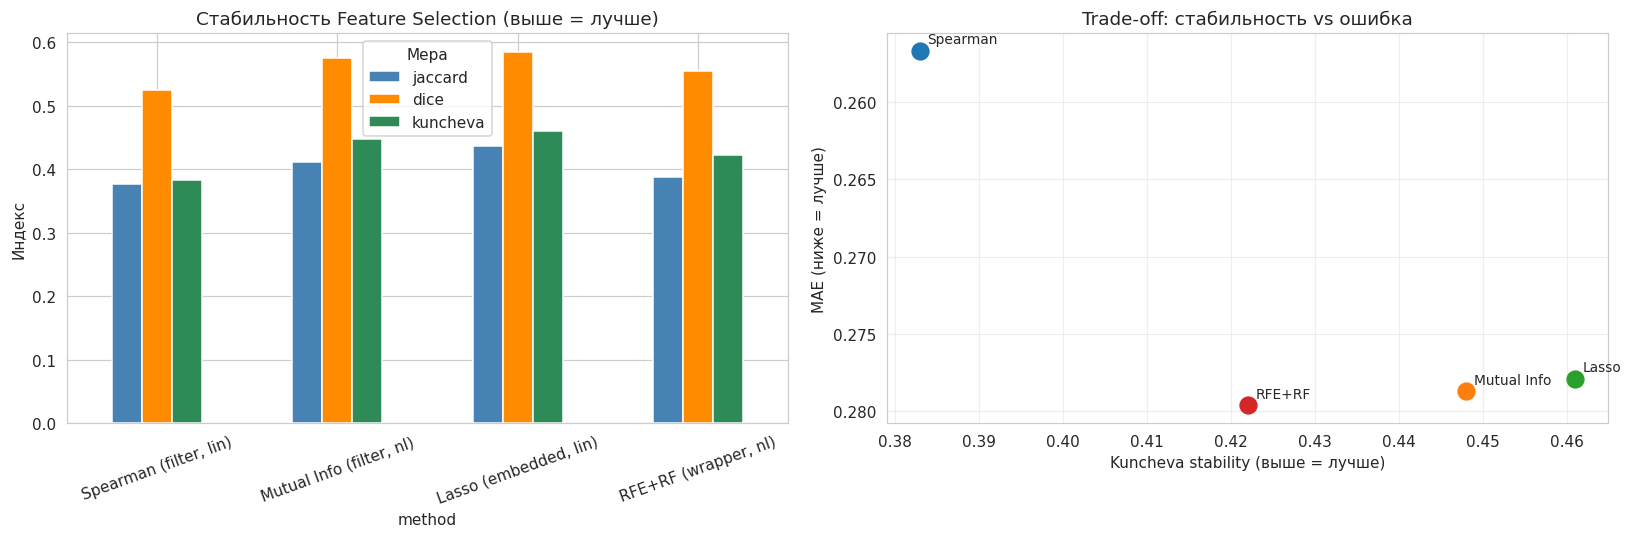


Loss (γ — вес стабильности):
                          Loss(γ=0.3)  Loss(γ=0.5)  Loss(γ=0.7)
method                                                         
Spearman (filter, lin)          0.828        0.768        0.707
Mutual Info (filter, nl)        0.863        0.774        0.685
Lasso (embedded, lin)           0.857        0.766        0.675
RFE+RF (wrapper, nl)            0.873        0.789        0.705

Лучший метод по γ=0.5: Lasso (embedded, lin)


In [36]:
# объединяем
result = stab_df.join(perf_df)
print('\n=== ИТОГ ===')
print(result)

# стабильность vs MAE
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Слева — все три меры стабильности
result[['jaccard', 'dice', 'kuncheva']].plot(kind='bar', ax=axes[0],
                                              color=['steelblue', 'darkorange', 'seagreen'])
axes[0].set_title('Стабильность Feature Selection (выше = лучше)')
axes[0].set_ylabel('Индекс')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].legend(title='Мера')
axes[0].tick_params(axis='x', rotation=20)

# Справа — Stability/Performance trade-off
ax = axes[1]
for name in result.index:
    ax.scatter(result.loc[name, 'kuncheva'], result.loc[name, 'MAE_mean'],
               s=120, label=name)
    ax.annotate(name.split(' (')[0],
                (result.loc[name, 'kuncheva'], result.loc[name, 'MAE_mean']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_xlabel('Kuncheva stability (выше = лучше)')
ax.set_ylabel('MAE (ниже = лучше)')
ax.set_title('Trade-off: стабильность vs ошибка')
ax.grid(True, alpha=0.3)
# Лучший — левый верхний угол по MAE и правый по стабильности
ax.invert_yaxis()

plt.tight_layout()
plt.show()


# Loss из лекции: γ·(1-stability) + (1-γ)·MAE_normalized
mae_norm = result['MAE_mean'] / result['MAE_mean'].max()
for gamma in [0.3, 0.5, 0.7]:
    result[f'Loss(γ={gamma})'] = gamma * (1 - result['kuncheva']) + (1 - gamma) * mae_norm
print('\nLoss (γ — вес стабильности):')
print(result[[c for c in result.columns if 'Loss' in c]].round(3))
print(f'\nЛучший метод по γ=0.5: {result["Loss(γ=0.5)"].idxmin()}')

In [37]:
mae_norm = perf_df['MAE_mean'] / perf_df['MAE_mean'].max()

final = pd.DataFrame({
    'Kuncheva':  stab_df['kuncheva'],
    'MAE':       perf_df['MAE_mean'],
    'MAE_std':   perf_df['MAE_std'],
})

for gamma in [0.3, 0.5, 0.7]:
    final[f'Loss(γ={gamma})'] = (gamma * (1 - final['Kuncheva'])
                                  + (1 - gamma) * mae_norm)

print(final.round(4))
print()
for gamma in [0.3, 0.5, 0.7]:
    best = final[f'Loss(γ={gamma})'].idxmin()
    print(f'γ={gamma}: лучший метод = {best}')

                          Kuncheva     MAE  MAE_std  Loss(γ=0.3)  Loss(γ=0.5)  \
method                                                                          
Spearman (filter, lin)       0.383  0.2567   0.0250       0.8278       0.7675   
Mutual Info (filter, nl)     0.448  0.2787   0.0508       0.8633       0.7744   
Lasso (embedded, lin)        0.461  0.2779   0.0592       0.8574       0.7665   
RFE+RF (wrapper, nl)         0.422  0.2796   0.0523       0.8734       0.7890   

                          Loss(γ=0.7)  
method                                 
Spearman (filter, lin)         0.7073  
Mutual Info (filter, nl)       0.6854  
Lasso (embedded, lin)          0.6755  
RFE+RF (wrapper, nl)           0.7046  

γ=0.3: лучший метод = Spearman (filter, lin)
γ=0.5: лучший метод = Lasso (embedded, lin)
γ=0.7: лучший метод = Lasso (embedded, lin)


# Конкретный списки фичей

In [38]:
# Финальный отбор: фичи, попавшие в set метода на ≥3 из 5 фолдов
final_features = {}
for name, sets in feature_sets.items():
    counter = pd.Series(0, index=X_features.columns)
    for s in sets:
        counter[list(s)] += 1
    final_features[name] = sorted(counter[counter >= 3].index.tolist())

# Сохраняем
import json
with open('feature_sets.json', 'w', encoding='utf-8') as f:
    json.dump(final_features, f, indent=2, ensure_ascii=False)

# Показываем что внутри
for name, feats in final_features.items():
    print(f'\n{name} — {len(feats)} фичей:')
    for f in feats:
        print(f'  • {f}')


Spearman (filter, lin) — 15 фичей:
  • balance_ewm_20
  • balance_lag_1
  • balance_lag_5
  • balance_rollmean_10
  • balance_rollmean_20
  • dow
  • holiday_run_before
  • io_ratio_lag1
  • is_post_holiday
  • is_pre_tax_28_3d
  • is_tax_25_day
  • is_tax_25_window
  • outcome_lag_1
  • outcome_lag_20
  • outcome_lag_5

Mutual Info (filter, nl) — 21 фичей:
  • balance_lag_3
  • balance_rollmax_10
  • balance_rollmax_5
  • balance_rollmean_10
  • balance_rollmean_20
  • days_from_month_start
  • days_to_month_end
  • days_to_tax_15
  • days_to_tax_25
  • days_to_tax_28
  • dom
  • dow
  • income_lag_1
  • income_lag_2
  • is_holiday
  • is_nonworking
  • is_post_holiday
  • outcome_lag_1
  • outcome_rollmean_5
  • ruonia_lag1
  • usd_rub_lag1

Lasso (embedded, lin) — 18 фичей:
  • abs_balance_lag1
  • balance_lag_5
  • cbr_key_rate_diff5
  • cbr_key_rate_lag1
  • holiday_run_before
  • is_post_holiday
  • is_post_tax_15_3d
  • is_post_tax_28_3d
  • is_pre_tax_28_3d
  • is_quarter_tax_

# Моделирование

In [39]:
result.head()

,jaccard,dice,kuncheva,MAE_mean,MAE_std,Loss(γ=0.3),Loss(γ=0.5),Loss(γ=0.7)
method,,,,,,,,
"Spearman (filter, lin)",0.376,0.525,0.383,0.2567,0.0250,0.827768,0.767549,0.707329
"Mutual Info (filter, nl)",0.411,0.575,0.448,0.2787,0.0508,0.863347,0.774391,0.685434
"Lasso (embedded, lin)",0.437,0.585,0.461,0.2779,0.0592,0.857444,0.766460,0.675476
"RFE+RF (wrapper, nl)",0.388,0.555,0.422,0.2796,0.0523,0.873400,0.789000,0.704600


In [43]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

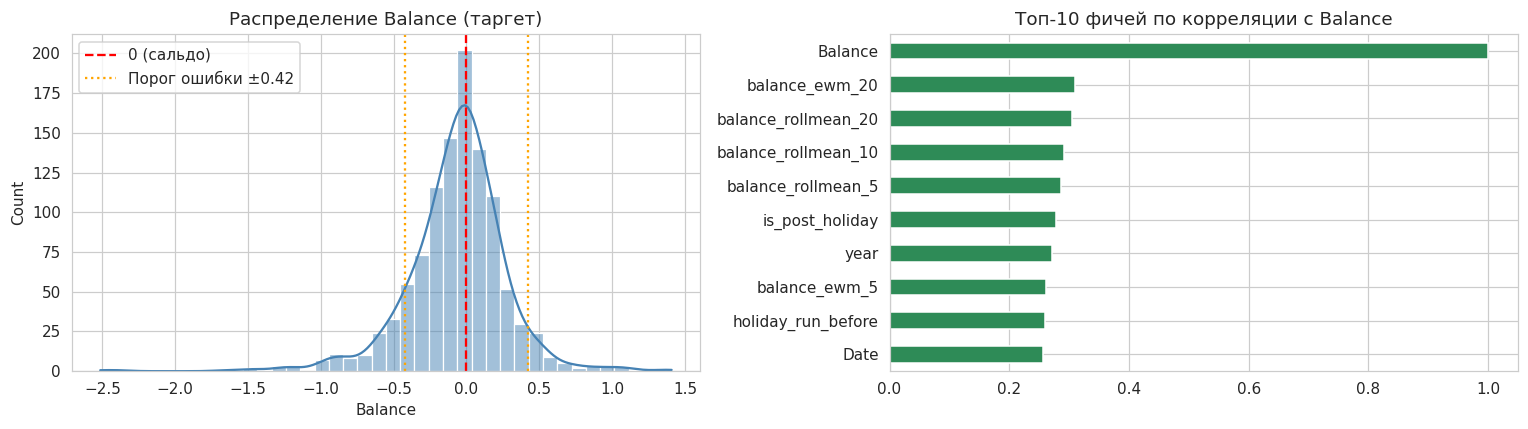

In [51]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Распределение таргета
sns.histplot(y, bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(0, color='red', ls='--', label='0 (сальдо)')
axes[0].axvline(0.42, color='orange', ls=':', label='Порог ошибки ±0.42')
axes[0].axvline(-0.42, color='orange', ls=':')
axes[0].set_title('Распределение Balance (таргет)')
axes[0].legend()

# Корреляция топ-фичей с таргетом
top_corr = X.corrwith(y).abs().sort_values(ascending=False).head(10)
top_corr.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Топ-10 фичей по корреляции с Balance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


#Линейные модели



In [40]:
RANDOM_STATE = 42
TARGET_ABS_ERROR = 0.42
N_SPLITS = 5
ARIMAX_SPLITS = 3
SEASONAL_PERIOD = 5

y = pd.Series(y).reset_index(drop=True)
X_features = X_features.reset_index(drop=True)

split_idx = int(len(X_features) * 0.8)

X_train = X_features.iloc[:split_idx].copy()
X_test  = X_features.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test  = y.iloc[split_idx:].copy()


# метрика
def business_report(y_true, y_pred, model_name: str):
    err = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    return pd.Series({
        "model": model_name,
        "MAE": float(err.mean()),
        "within_0.42_share": float((err <= TARGET_ABS_ERROR).mean()),
        "max_error": float(err.max())
    })


# CV
def cv_mae(y_series, exog=None, order=(1,0,0), seasonal_order=(0,0,0,0), n_splits=5):
    y_series = pd.Series(y_series).reset_index(drop=True)
    exog = None if exog is None else pd.DataFrame(exog).reset_index(drop=True)
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = []
    for tr_idx, va_idx in tscv.split(y_series):
        y_tr, y_va = y_series.iloc[tr_idx], y_series.iloc[va_idx]
        try:
            if exog is None:
                if seasonal_order == (0,0,0,0):
                    model = ARIMA(y_tr, order=order).fit()
                else:
                    model = SARIMAX(
                        y_tr,
                        order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    ).fit(disp=False)
                pred = model.forecast(len(va_idx))
            else:
                X_tr, X_va = exog.iloc[tr_idx], exog.iloc[va_idx]
                model = SARIMAX(
                    y_tr,
                    exog=X_tr,
                    order=order,
                    seasonal_order=seasonal_order,
                    trend="c",
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(disp=False)
                pred = model.forecast(len(va_idx), exog=X_va)
            scores.append(mean_absolute_error(y_va, pred))
        except:
            return np.inf
    return float(np.mean(scores))

# Arima
def grid_search_arima(y_series):
    best_order = None
    best_score = np.inf
    for p in [0,1,2,3]:
        for d in [0,1]:
            for q in [0,1,2,3]:
                score = cv_mae(y_series, order=(p,d,q), seasonal_order=(0,0,0,0), n_splits=N_SPLITS)
                if score < best_score:
                    best_score = score
                    best_order = (p,d,q)
    return best_order, best_score

# Sarima
def grid_search_sarima(y_series):
    best_params = None
    best_score = np.inf
    for p in [0,1,2]:
        for d in [0,1]:
            for q in [0,1,2]:
                for P in [0,1]:
                    for D in [0]:
                        for Q in [0,1]:
                            score = cv_mae(
                                y_series,
                                order=(p,d,q),
                                seasonal_order=(P,D,Q,SEASONAL_PERIOD),
                                n_splits=N_SPLITS
                            )
                            if score < best_score:
                                best_score = score
                                best_params = ((p,d,q),(P,D,Q,SEASONAL_PERIOD))
    return best_params, best_score

# ARIMAX FAST
def grid_search_arimax_fast(y_series, X_exog):
    spearman_cols = final_features.get("Spearman (filter, lin)", list(X_features.columns))
    TOP_K = 12
    selected_cols = spearman_cols[:TOP_K]
    X_exog = pd.DataFrame(X_exog[selected_cols]).reset_index(drop=True)
    best_params = None
    best_score = np.inf
    tscv = TimeSeriesSplit(n_splits=ARIMAX_SPLITS)
    for p in [0,1,2]:
        for d in [0,1]:
            for q in [0,1]:
                for P in [0,1]:
                    for D in [0]:
                        for Q in [0,1]:
                            scores = []
                            for tr_idx, va_idx in tscv.split(y_series):
                                y_tr = y_series.iloc[tr_idx]
                                y_va = y_series.iloc[va_idx]
                                X_tr = X_exog.iloc[tr_idx]
                                X_va = X_exog.iloc[va_idx]
                                try:
                                    model = SARIMAX(
                                        y_tr,
                                        exog=X_tr,
                                        order=(p,d,q),
                                        seasonal_order=(P,D,Q,SEASONAL_PERIOD),
                                        trend="c",
                                        enforce_stationarity=False,
                                        enforce_invertibility=False
                                    ).fit(disp=False)
                                    pred = model.forecast(len(va_idx), exog=X_va)
                                    scores.append(mean_absolute_error(y_va, pred))
                                except:
                                    scores.append(np.inf)
                                    break
                            score = np.mean(scores)
                            if score < best_score:
                                best_score = score
                                best_params = ((p,d,q),(P,D,Q,SEASONAL_PERIOD))
    return best_params, best_score, selected_cols

# Arima
best_order_arima, cv_arima = grid_search_arima(y_train)
print("ARIMA:", best_order_arima, cv_arima)
arima_fit = ARIMA(y_train, order=best_order_arima).fit()
arima_pred = arima_fit.forecast(len(y_test))
arima_report = business_report(y_test, arima_pred, "ARIMA")
print(arima_report)

# Sarima
best_params_sarima, cv_sarima = grid_search_sarima(y_train)
best_order_sarima, best_season_sarima = best_params_sarima
print("SARIMA:", best_order_sarima, best_season_sarima, cv_sarima)
sarima_fit = SARIMAX(
    y_train,
    order=best_order_sarima,
    seasonal_order=best_season_sarima,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
sarima_pred = sarima_fit.forecast(len(y_test))
sarima_report = business_report(y_test, sarima_pred, "SARIMA")
print(sarima_report)

# Arimax
best_params_arimax, cv_arimax, used_cols = grid_search_arimax_fast(
    y_train,
    X_train
)
best_order_arimax, best_season_arimax = best_params_arimax
X_train_arimax = X_train[used_cols]
X_test_arimax = X_test[used_cols]
print("ARIMAX:", best_order_arimax, best_season_arimax, cv_arimax)
arimax_fit = SARIMAX(
    y_train,
    exog=X_train_arimax,
    order=best_order_arimax,
    seasonal_order=best_season_arimax,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
arimax_pred = arimax_fit.forecast(len(y_test), exog=X_test_arimax)
arimax_report = business_report(y_test, arimax_pred, "ARIMAX")
print(arimax_report)

# линейные модели
selected_cols = final_features.get("Spearman (filter, lin)", list(X_features.columns))
X_train_lin = X_train[selected_cols]
X_test_lin = X_test[selected_cols]
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
models = {
    "Lasso": (Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(max_iter=50000))
    ]), {"model__alpha": np.logspace(-4, 0, 20)}),

    "Ridge": (Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ]), {"model__alpha": np.logspace(-4, 2, 20)}),

    "ElasticNet": (Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(max_iter=50000))
    ]), {
        "model__alpha": np.logspace(-4, 0, 15),
        "model__l1_ratio": [0.1,0.3,0.5,0.7,0.9]
    })
}

results = []
for name,(pipe,params) in models.items():
    gs = GridSearchCV(pipe, params, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
    gs.fit(X_train_lin, y_train)
    pred = gs.predict(X_test_lin)
    rep = business_report(y_test, pred, name)
    rep["cv_mae"] = -gs.best_score_
    print(name, gs.best_params_, rep)
    results.append(rep)
summary = pd.DataFrame(results)
print(summary.sort_values("MAE"))


ARIMA: (2, 0, 3) 0.24125705646420129
model                   ARIMA
MAE                  0.266123
within_0.42_share    0.806452
max_error             2.48801
dtype: object
SARIMA: (2, 0, 2) (1, 0, 1, 5) 0.24051448246509252
model                  SARIMA
MAE                  0.276157
within_0.42_share    0.797235
max_error            2.514859
dtype: object
ARIMAX: (0, 0, 1) (1, 0, 0, 5) 0.23901130629180348
model                ARIMAX_FAST
MAE                     0.204027
within_0.42_share       0.880184
max_error               2.212129
dtype: object
Lasso {'model__alpha': np.float64(0.03359818286283781)} model                   Lasso
MAE                  0.229444
within_0.42_share    0.852535
max_error            2.372818
cv_mae               0.234975
dtype: object
Ridge {'model__alpha': np.float64(100.0)} model                   Ridge
MAE                  0.204628
within_0.42_share    0.884793
max_error            2.164247
cv_mae               0.256773
dtype: object
ElasticNet {'model__a

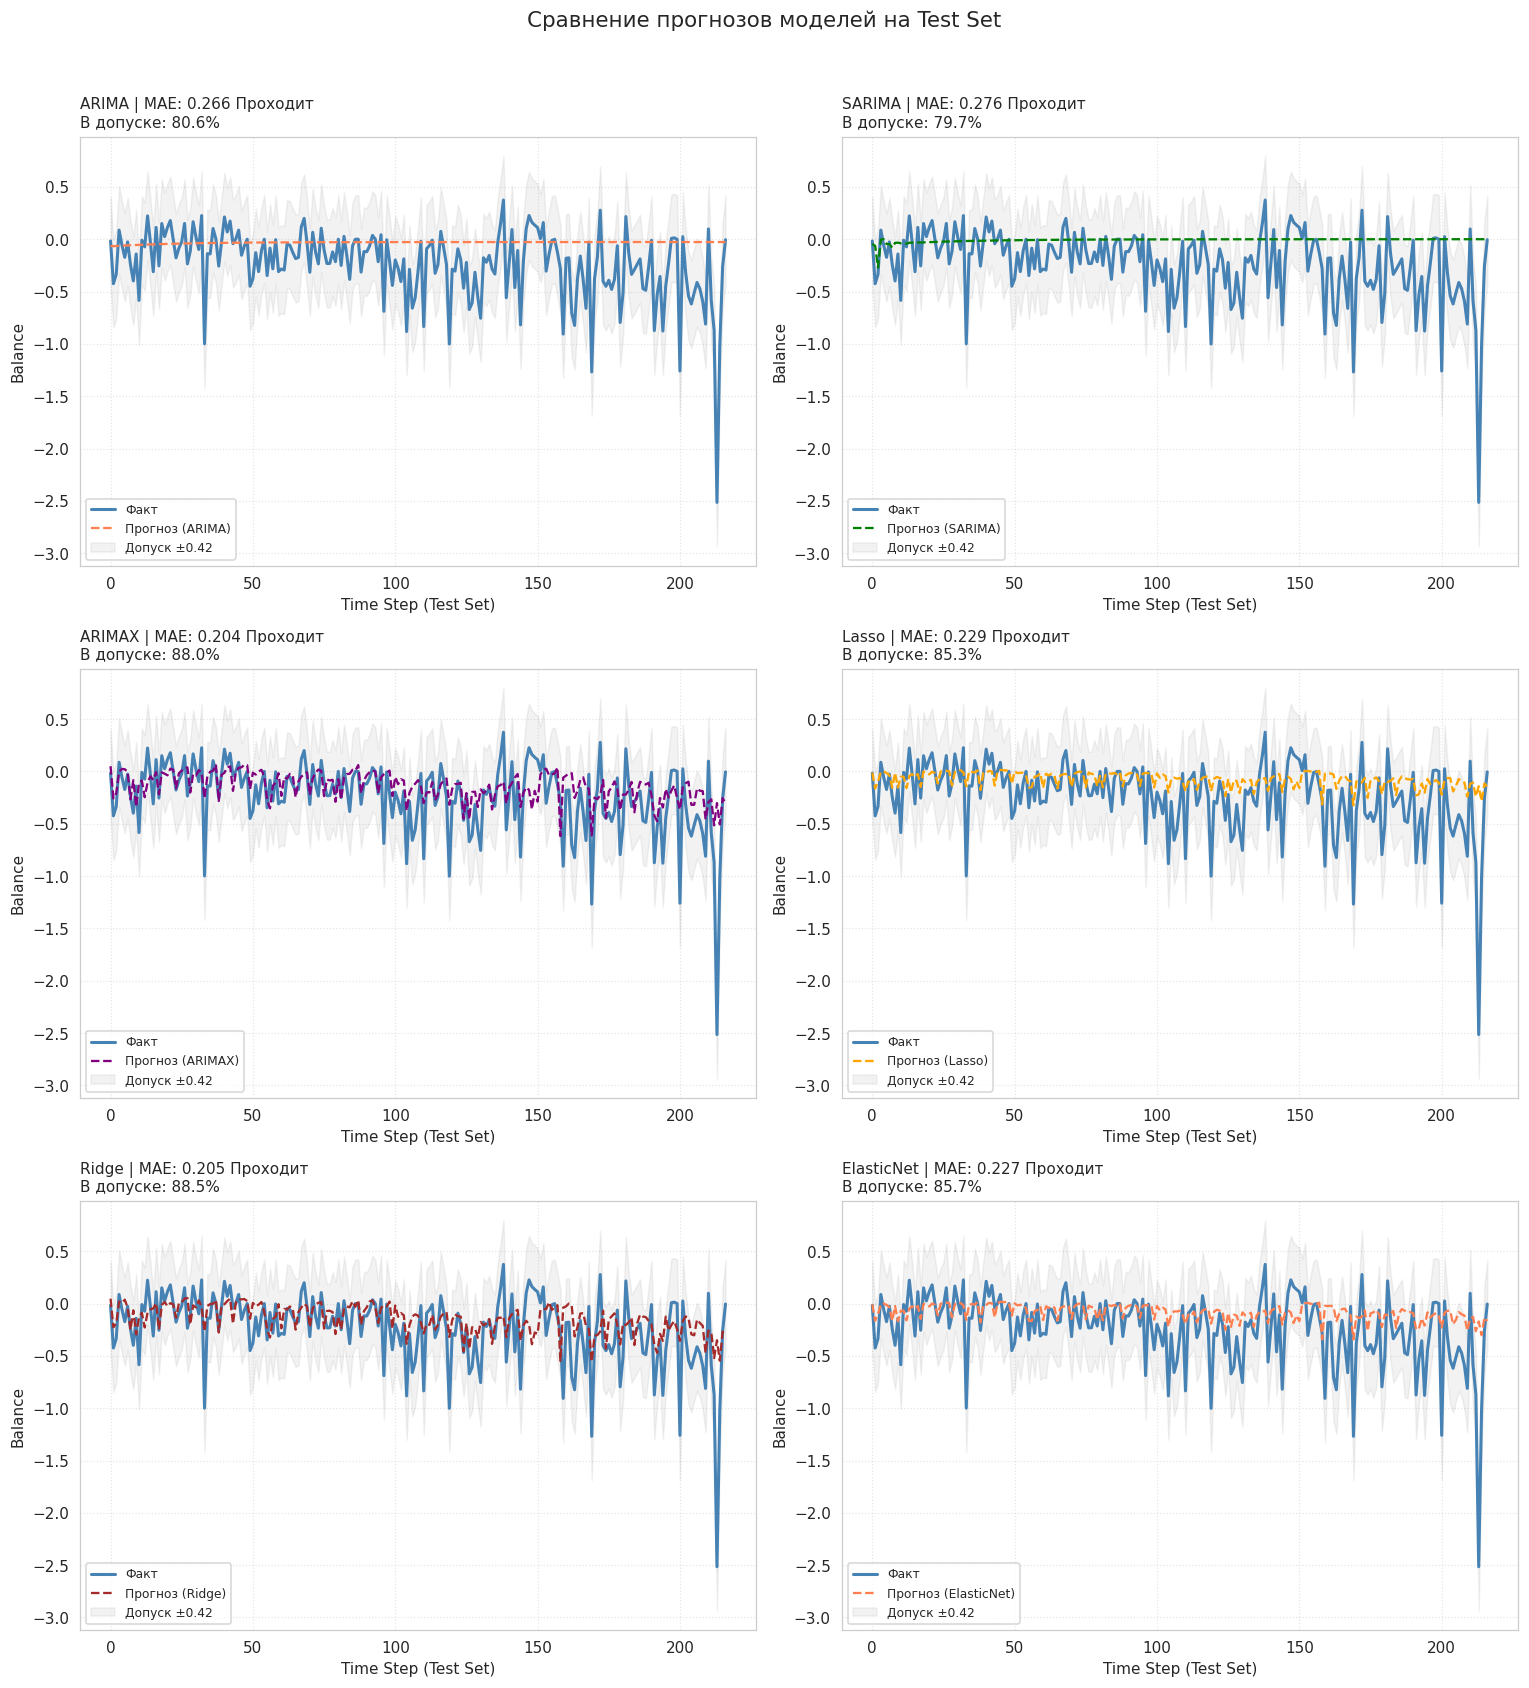

In [62]:
# Графики
y_test_plot = y_test.reset_index(drop=True)
test_index = y_test_plot.index
def plot_all_forecasts(y_true, predictions_dict, target_error=TARGET_ABS_ERROR):
    """
    predictions_dict: dict {
        'ModelName': {
            'pred': array-like,
            'report': pd.Series (из business_report)
        }
    }
    """
    n_models = len(predictions_dict)

    # Настройка сетки графиков
    n_cols = 2
    n_rows = (n_models + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten() if n_models > 1 else [axes]

    # Цвета для линий прогноза
    colors = ['coral', 'green', 'purple', 'orange', 'brown']
    for i, (model_name, data) in enumerate(predictions_dict.items()):
        ax = axes[i]
        y_pred = data['pred']
        report = data['report']
        # Расчет ошибки
        err = np.abs(np.asarray(y_true) - np.asarray(y_pred))
        # Факт
        ax.plot(test_index, y_true.values, label='Факт', color='steelblue', lw=2)
        # Прогноза
        color = colors[i % len(colors)]
        ax.plot(test_index, y_pred, label=f'Прогноз ({model_name})', color=color, lw=1.5, ls='--')
        ax.fill_between(test_index,
        np.asarray(y_true) - target_error,
        np.asarray(y_true) + target_error,
        alpha=0.1, color='gray', label=f'Допуск ±{target_error}')

        # Метрики
        mae_val = report['MAE']
        share_val = report['within_0.42_share'] * 100
        status_icon = "Проходит" if mae_val <= target_error else "Не проходит"
        title_text = f"{model_name} | MAE: {mae_val:.3f} {status_icon}\nВ допуске: {share_val:.1f}%"
        ax.set_title(title_text, fontsize=10, loc='left')
        ax.set_ylabel('Balance')
        ax.set_xlabel('Time Step (Test Set)')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.5)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Сравнение прогнозов моделей на Test Set', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Словарь для визуализации

# ARIMA
preds_dict = {
    "ARIMA": {
        "pred": arima_pred,
        "report": arima_report
    },
    # SARIMA
    "SARIMA": {
        "pred": sarima_pred,
        "report": sarima_report
    },
    # ARIMAX
    "ARIMAX": {
        "pred": arimax_pred,
        "report": arimax_report
    }
}
linear_predictions = {}
for name, (pipe, params) in models.items():

    # Обучаем лучшую конфигурацию заново на train
    gs = GridSearchCV(pipe, params, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
    gs.fit(X_train_lin, y_train)
    pred = gs.predict(X_test_lin)
    rep = business_report(y_test, pred, name)
    linear_predictions[name] = {
        "pred": pred,
        "report": rep
    }

# Объединяем модели
all_predictions = {**preds_dict, **linear_predictions}
plot_all_forecasts(y_test_plot, all_predictions)

In [50]:
# Нелинейные модели
def business_report(y_true, y_pred, model_name: str) -> pd.Series:
    err = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    return pd.Series({
        "model": model_name,
        "MAE": float(err.mean()),
        "within_0.42_share": float((err <= TARGET_ABS_ERROR).mean()),
        "max_abs_error": float(err.max()),
    })
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
X_train_nl = X_train.copy()
X_test_nl = X_test.copy()

# Random forest
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])
rf_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [8, 12, None],
    "model__min_samples_leaf": [1, 3, 5],
    "model__max_features": ["sqrt", 0.7]
}
rf_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1
)
rf_search.fit(X_train_nl, y_train)
rf_pred = rf_search.predict(X_test_nl)
rf_report = business_report(y_test, rf_pred, "RandomForest")
rf_report["cv_best_mae"] = -rf_search.best_score_
print("RANDOM FOREST")
print("Best params:", rf_search.best_params_)
print(rf_report)

# Extra trees
et_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])
et_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [8, 12, None],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.7]
}
et_search = GridSearchCV(
    estimator=et_pipe,
    param_grid=et_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1
)
et_search.fit(X_train_nl, y_train)
et_pred = et_search.predict(X_test_nl)
et_report = business_report(y_test, et_pred, "ExtraTrees")
et_report["cv_best_mae"] = -et_search.best_score_
print("EXTRA TREES")
print("Best params:", et_search.best_params_)
print(et_report)

# градиентный бустинг
gb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
])
gb_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_leaf": [1, 3, 5]
}
gb_search = GridSearchCV(
    estimator=gb_pipe,
    param_grid=gb_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1
)
gb_search.fit(X_train_nl, y_train)
gb_pred = gb_search.predict(X_test_nl)
gb_report = business_report(y_test, gb_pred, "GradientBoosting")
gb_report["cv_best_mae"] = -gb_search.best_score_
print("GRADIENT BOOSTING")
print("Best params:", gb_search.best_params_)
print(gb_report)

RANDOM FOREST
Best params: {'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 400}
model                RandomForest
MAE                      0.201141
within_0.42_share        0.880184
max_abs_error            2.274716
cv_best_mae              0.242015
dtype: object
EXTRA TREES
Best params: {'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__n_estimators': 300}
model                ExtraTrees
MAE                    0.209169
within_0.42_share      0.875576
max_abs_error          2.329241
cv_best_mae            0.237103
dtype: object
GRADIENT BOOSTING
Best params: {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__min_samples_leaf': 3, 'model__n_estimators': 100}
model                GradientBoosting
MAE                          0.231557
within_0.42_share            0.847926
max_abs_error                2.420311
cv_best_mae                  0.263413
dtype: object


In [49]:
# общая таблица
nonlinear_summary = pd.DataFrame([
    rf_report,
    et_report,
    gb_report
])
print(nonlinear_summary.sort_values("MAE"))

              model       MAE  within_0.42_share  max_abs_error  cv_best_mae
0      RandomForest  0.201141           0.880184       2.274716     0.242015
1        ExtraTrees  0.209169           0.875576       2.329241     0.237103
2  GradientBoosting  0.231557           0.847926       2.420311     0.263413


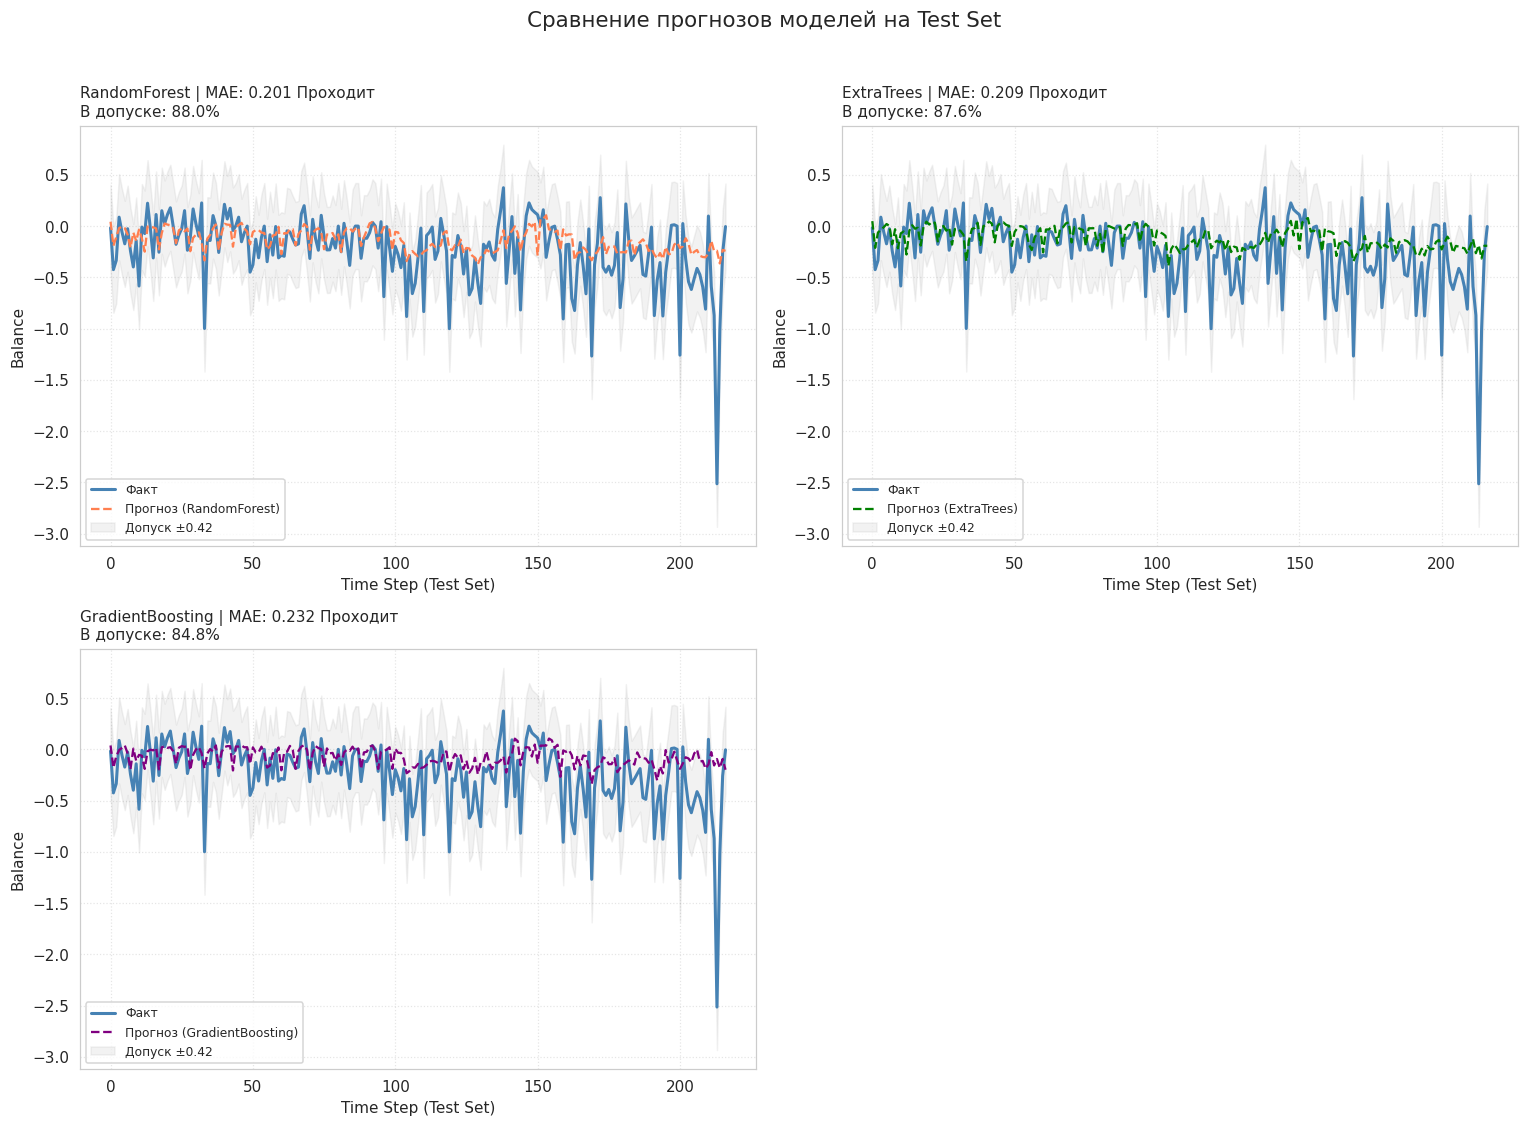

In [63]:
# Словарь для нелинейных моделей
nonlinear_predictions = {
    "RandomForest": {
        "pred": rf_pred,
        "report": rf_report
    },
    "ExtraTrees": {
        "pred": et_pred,
        "report": et_report
    },
    "GradientBoosting": {
        "pred": gb_pred,
        "report": gb_report
    }
}

# Визуализация
plot_all_forecasts(y_test_plot, nonlinear_predictions)